<div style="font-size: 25px;width:100%;color: white; text-shadow: 0px 0px 15px rgb(0, 211, 11);text-align: center;border-bottom: 2px solid rgb(0, 211, 11);">Import Library

In [2]:
import numpy as np
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns 
import sweetviz as sv

# Load Dataset

In [3]:
df = pd.read_csv('E:/Machin Learning/tamrin/eighteen_nineteen_university_datasets.csv',encoding='unicode_escape')

### Top 5 data

In [4]:
df.head(5)

,World Rank,Institution,Location,National Rank,Quality of Education,Alumni Employment,Quality of Faculty,Research Output,Quality Publications,Influence,Citations,Score
0,1,Harvard University,USA,1,2,1,1,1,1,1,1,100.0
1,2,Stanford University,USA,2,10,3,2,10,4,3,2,96.7
2,3,Massachusetts Institute of Technology,USA,3,3,11,3,30,15,2,6,95.1
3,4,University of Cambridge,United Kingdom,1,5,19,6,12,8,6,19,94.0
4,5,University of Oxford,United Kingdom,2,9,25,10,9,5,7,4,93.2


# Size of Data

In [5]:
df.shape

(1000, 12)

# Check The data type

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   World Rank            1000 non-null   int64  
 1   Institution           1000 non-null   object 
 2   Location              1000 non-null   object 
 3   National Rank         1000 non-null   int64  
 4   Quality of Education  1000 non-null   object 
 5   Alumni Employment     1000 non-null   object 
 6   Quality of Faculty    1000 non-null   object 
 7   Research Output       1000 non-null   object 
 8   Quality Publications  1000 non-null   object 
 9   Influence             1000 non-null   object 
 10  Citations             1000 non-null   object 
 11  Score                 1000 non-null   float64
dtypes: float64(1), int64(2), object(9)
memory usage: 93.9+ KB


### Describe the Numerical Data

In [7]:
df.describe()

,World Rank,National Rank,Score
count,1000.000000,1000.00000,1000.000000
mean,500.500000,40.02300,75.034300
std,288.819436,49.22871,4.670858
min,1.000000,1.00000,69.800000
25%,250.750000,6.00000,71.500000
50%,500.500000,21.00000,73.750000
75%,750.250000,51.00000,77.300000
max,1000.000000,213.00000,100.000000


### global and local rankings

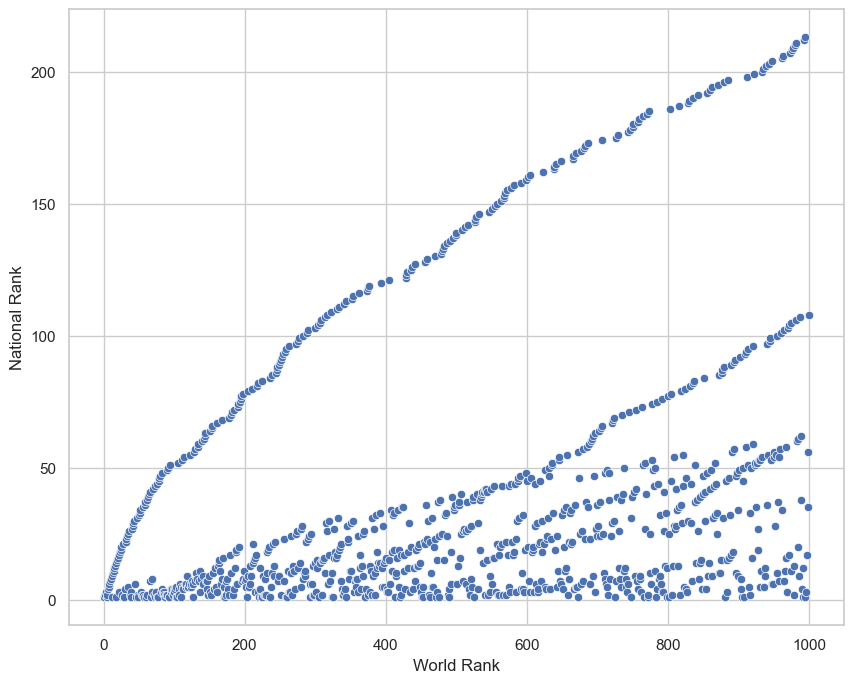

In [8]:
df.columns = df.columns.str.strip()

plt.figure(figsize=(10,8))
sns.set_theme(style='whitegrid')

sns.scatterplot(
    x='World Rank',
    y='National Rank',   # بدون فاصله اضافه!
    data=df
)

plt.show()


### Collecting duplicate data

In [9]:
df.duplicated().sum()

0

### Datatype

In [10]:
def dis(df):
    variable = []
    datatpe = []
    count = []
    unique = []
    missing = []
    percent = []
    for item in df.columns:
        variable.append (item)
        datatpe.append(df[item].dtype)
        count.append(len(df[item]))
        unique.append(len(df[item].unique()))
        missing.append(df[item].isna().sum())
        percentage =df[item].isna().sum()*100/len(df[item])
        percent.append(f"{percentage:.2f}%")
    
    output = pd.DataFrame({
        'variable':variable,
        'datatype':datatpe,
        'count':count,
        'unique':unique,
        'missing':missing,
        'percentage':percent
      })
    


    return output

In [11]:
dis(df)

,variable,datatype,count,unique,missing,percentage
0,World Rank,int64,1000,1000,0,0.00%
1,Institution,object,1000,1000,0,0.00%
2,Location,object,1000,61,0,0.00%
3,National Rank,int64,1000,213,0,0.00%
4,Quality of Education,object,1000,404,0,0.00%
5,Alumni Employment,object,1000,492,0,0.00%
6,Quality of Faculty,object,1000,221,0,0.00%
7,Research Output,object,1000,905,0,0.00%
8,Quality Publications,object,1000,892,0,0.00%
9,Influence,object,1000,830,0,0.00%


### unique data

In [12]:
def dis2(df):
    unique = []
    variable = []
    d_type = []
    for item in df.columns:
        variable.append (item)
        unique.append(df[item].unique())
        d_type.append(df[item].dtype)
    output = pd.DataFrame({
        'variable':variable,
        'datatype':d_type,
        'unique':unique,
      })
    


    return output

In [13]:
dis2(df)

,variable,datatype,unique
0,World Rank,int64,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
1,Institution,object,"[Harvard University, Stanford University, Mass..."
2,Location,object,"[USA, United Kingdom, Japan, Canada, Switzerla..."
3,National Rank,int64,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
4,Quality of Education,object,"[2, 10, 3, 5, 9, 7, 4, 16, 1, 13, 11, 17, 31, ..."
5,Alumni Employment,object,"[1, 3, 11, 19, 25, 52, 15, 13, 200, 22, 34, 8,..."
6,Quality of Faculty,object,"[1, 2, 3, 6, 10, 5, 4, 8, 7, 9, 12, 33, 30, 19..."
7,Research Output,object,"[1, 10, 30, 12, 9, 18, 146, 20, 127, 39, 37, 7..."
8,Quality Publications,object,"[1, 4, 15, 8, 5, 12, 99, 14, 81, 22, 19, 17, 1..."
9,Influence,object,"[1, 3, 2, 6, 7, 4, 28, 10, 13, 18, 11, 23, 17,..."


### list columns

In [14]:
print(df.columns.tolist())

['World Rank', 'Institution', 'Location', 'National Rank', 'Quality\xa0of Education', 'Alumni Employment', 'Quality\xa0of Faculty', 'Research Output', 'Quality Publications', 'Influence', 'Citations', 'Score']


### Edit column names

In [15]:
df.columns = df.columns.str.replace('\xa0', ' ')




### Columns that contain "-"

In [16]:
columns_with_dash = df.columns[(df == '-').any()]
print(columns_with_dash)

Index(['Quality of Education', 'Quality of Faculty'], dtype='object')


### What percentage of data "-"

In [17]:
ne = (df['Quality of Education'] == '-').sum()
print('number missing value Education: ',ne)
d=(ne/len(df))*100
print(f"Persentage missing Education: {d:.2f}%\n")
ne = (df['Quality of Faculty'] == '-').sum()
print('number missing value Faculty: ',ne)
d=(ne/len(df))*100
print(f"Persentage missing Faculty: {d:.2f}%")


number missing value Education:  597
Persentage missing Education: 59.70%

number missing value Faculty:  731
Persentage missing Faculty: 73.10%


### Quality of Education data unique

In [18]:
Quality_E = pd.unique(df['Quality of Education'].values.ravel())
Quality_E

array(['2', '10', '3', '5', '9', '7', '4', '16', '1', '13', '11', '17',
       '31', '14', '58', '24', '86', '47', '75', '37', '32', '-', '129',
       '98', '64', '25', '65', '29', '46', '93', '108', '40', '205', '61',
       '131', '206', '68', '173', '302', '165', '212', '83', '374', '171',
       '8', '71', '103', '91', '162', '134', '215', '166', '70', '49',
       '35', '572', '232', '95', '264', '19', '472', '96', '148', '186',
       '33', '117', '43', '267', '149', '231', '122', '187', '310', '97',
       '15', '583', '625', '271', '112', '188', '169', '192', '105',
       '102', '386', '589', '228', '34', '340', '109', '294', '281',
       '334', '586', '142', '363', '570', '400', '311', '73', '183',
       '140', '486', '343', '89', '69', '123', '85', '6', '317', '399',
       '82', '339', '48', '175', '455', '594', '23', '373', '67', '172',
       '338', '94', '292', '113', '619', '603', '401', '282', '303',
       '565', '60', '237', '209', '273', '144', '79', '384', '220'

### min and max columns

In [19]:
for item in df.columns:
    print('column is : ',df[item])
    print('max is : ',df[item].max())
    print('min is : ',df[item].min())

column is :  0         1
1         2
2         3
3         4
4         5
       ... 
995     996
996     997
997     998
998     999
999    1000
Name: World Rank, Length: 1000, dtype: int64
max is :  1000
min is :  1
column is :  0                         Harvard University
1                        Stanford University
2      Massachusetts Institute of Technology
3                    University of Cambridge
4                       University of Oxford
                       ...                  
995                      Aga Khan University
996                   University of Calcutta
997                         K?chi University
998                 Soonchunhyang University
999                Capital Normal University
Name: Institution, Length: 1000, dtype: object
max is :  Örebro University
min is :  AGH University of Science and Technology
column is :  0                 USA
1                 USA
2                 USA
3      United Kingdom
4      United Kingdom
            ...      
995 

### Replace the larger 1000 with 1001

In [20]:
df = df.applymap(lambda x: '1001' if isinstance(x, str) and (x == '-' or x == '> 1000') else x)


C:\Users\moham\AppData\Local\Temp\ipykernel_9032\577612554.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: '1001' if isinstance(x, str) and (x == '-' or x == '> 1000') else x)


### convert string && numbric

In [21]:
cols = ['Quality of Education', 'Alumni Employment', 'Quality of Faculty', 
        'Research Output', 'Quality Publications', 'Influence', 'Citations']

df[cols] = df[cols].apply(pd.to_numeric)


### corelation heatmap

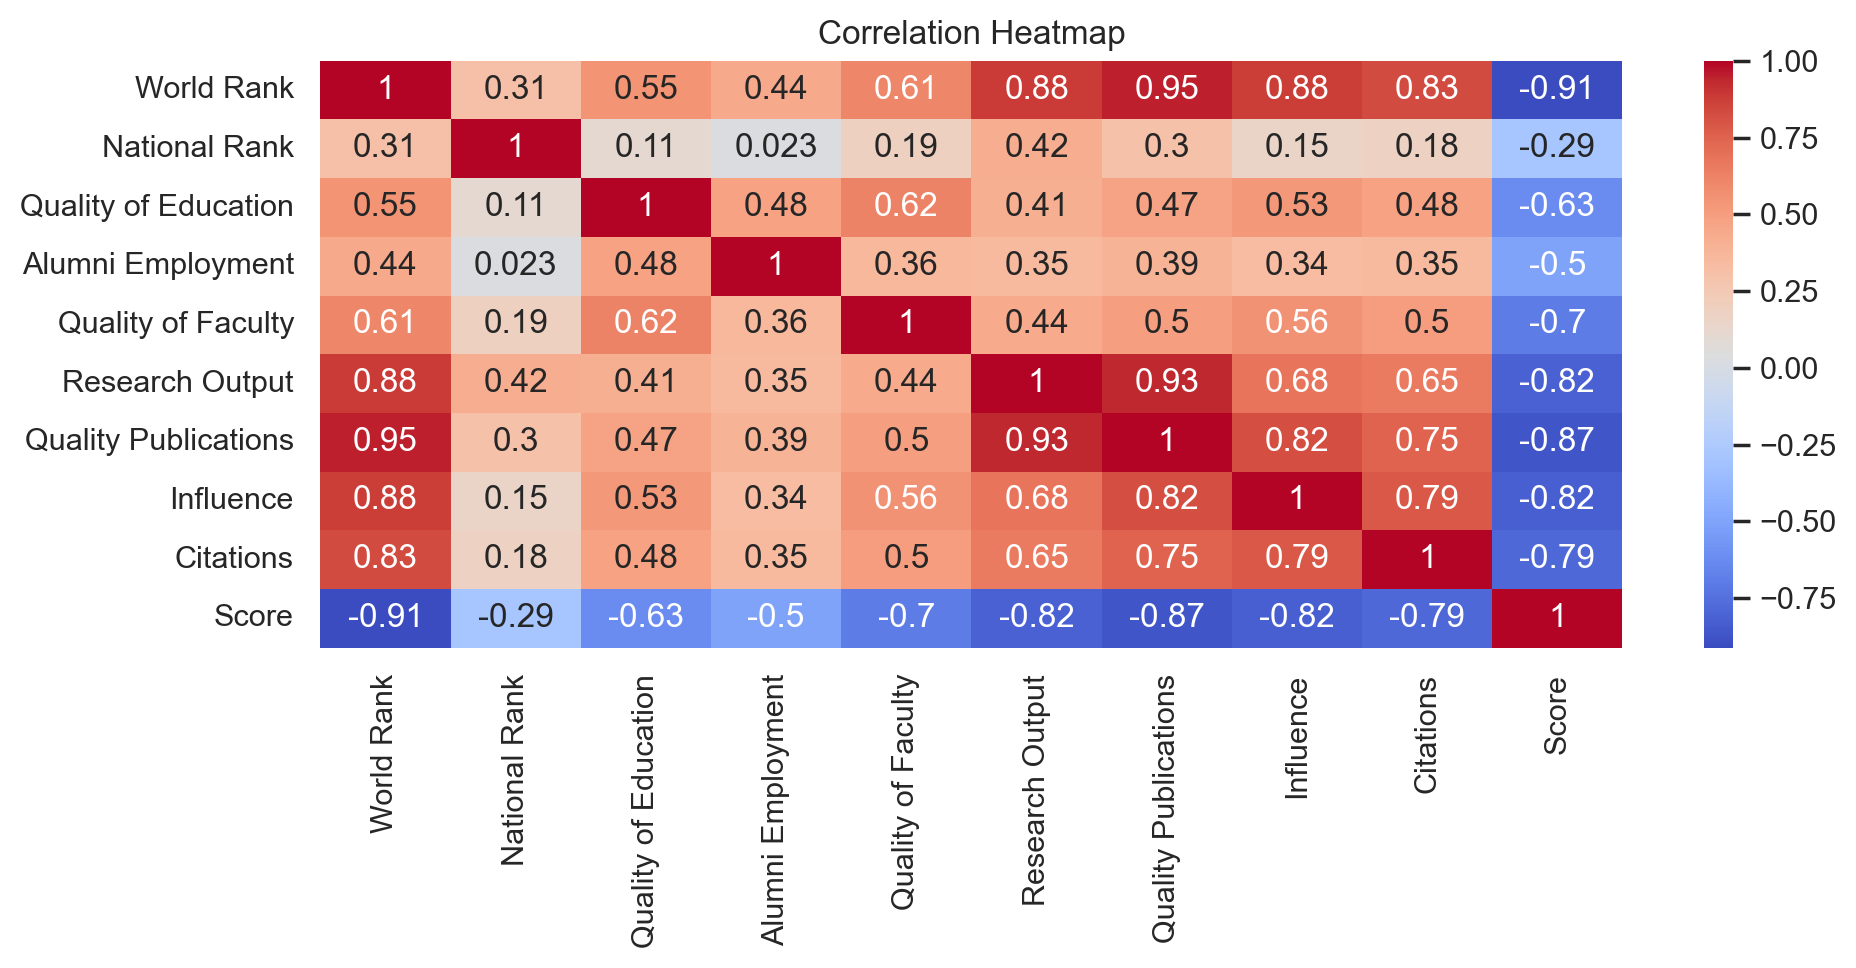

In [22]:
df_stored = df.select_dtypes(include=['number']).sort_values(by='World Rank')
fig, ax = plt.subplots(figsize=(10, 5), dpi=200)
corr = df_stored.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('plot_name.png', dpi=300, bbox_inches='tight')
plt.show()

### columns

In [23]:
df.columns

Index(['World Rank', 'Institution', 'Location', 'National Rank',
       'Quality of Education', 'Alumni Employment', 'Quality of Faculty',
       'Research Output', 'Quality Publications', 'Influence', 'Citations',
       'Score'],
      dtype='object')

### The relationship between Quality of Education and World Rank

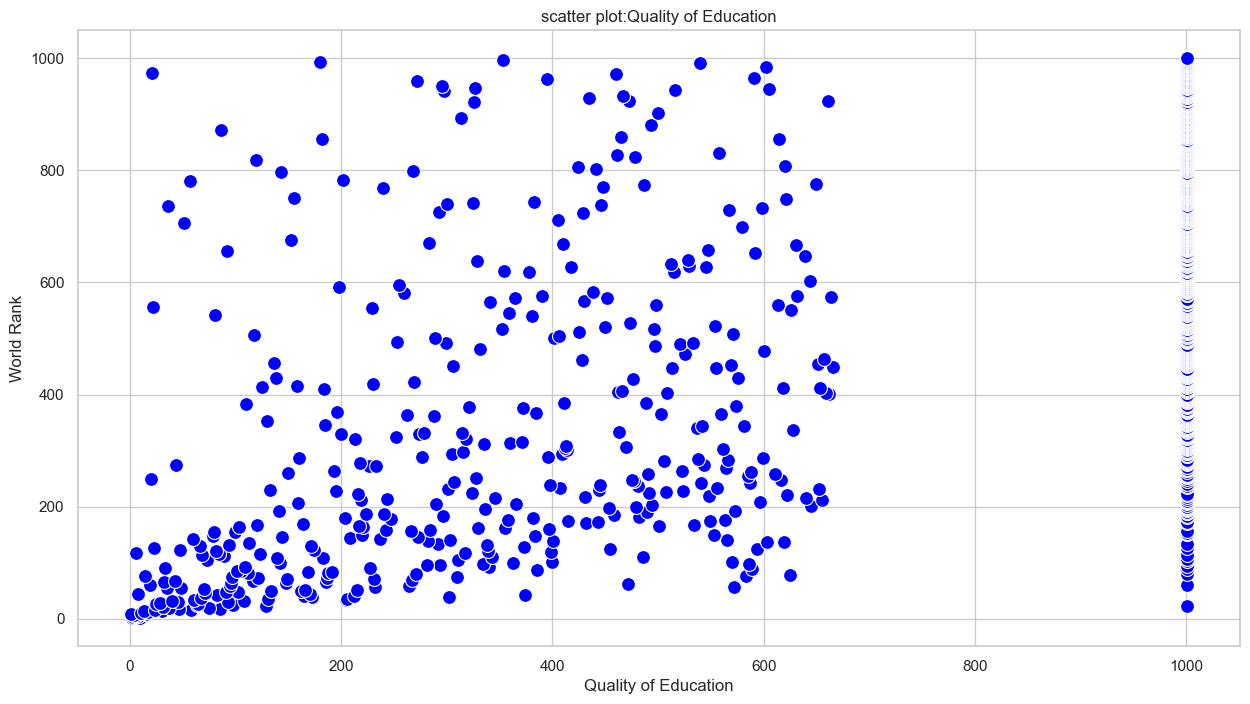

In [24]:
plt.figure(figsize=(15,8))
sns.set(style="whitegrid")
sns.scatterplot(x='Quality of Education' , y = 'World Rank' ,data =df,color ='blue',s=100)
plt.title('scatter plot:Quality of Education')
plt.xlabel('Quality of Education')
plt.ylabel('World Rank')
plt.savefig('plot_n1.png', dpi=300, bbox_inches='tight')
plt.show()

### The relationship between Quality of Faculty and World Rank

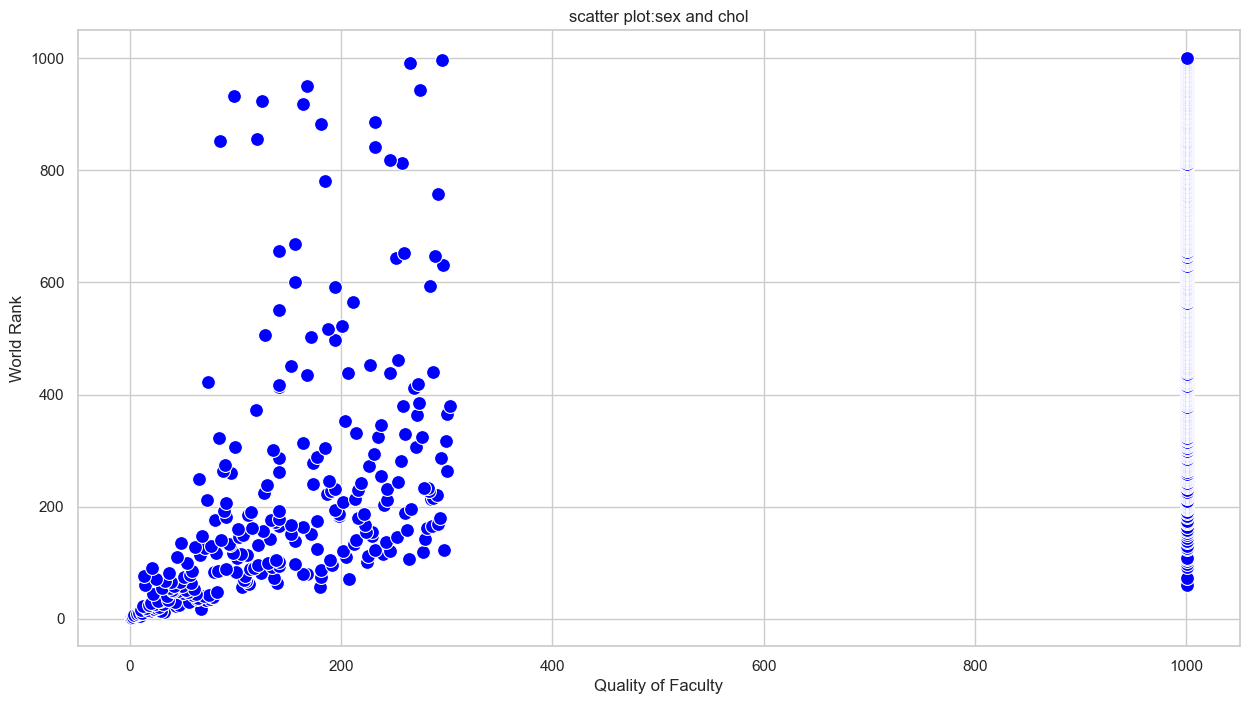

In [25]:
plt.figure(figsize=(15,8))
sns.set(style="whitegrid")
sns.scatterplot(x='Quality of Faculty' , y = 'World Rank' ,data =df,color ='blue',s=100)
plt.title('scatter plot:sex and chol')
plt.xlabel('Quality of Faculty')
plt.ylabel('World Rank')
plt.savefig('plot_n2.png', dpi=300, bbox_inches='tight')
plt.show()

### max data Quality of Education 

In [26]:
a = df['Quality of Education'].max()
a

1001

### Replace 1001 with the highest value plus 1

In [27]:
df.loc[:,'Quality of Education'] = df['Quality of Education'].replace(1001,a+1)

### show Quality of Education whit World Rank

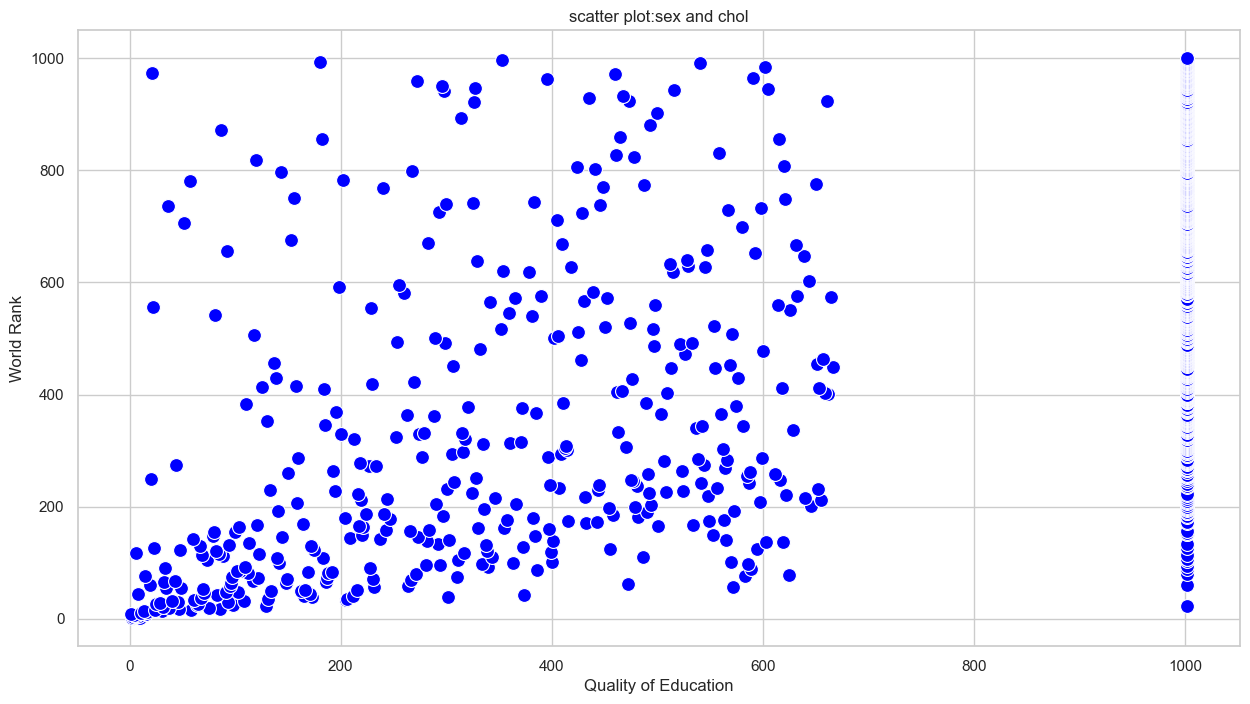

In [28]:
plt.figure(figsize=(15,8))
sns.set(style="whitegrid")
sns.scatterplot(x='Quality of Education' , y = 'World Rank' ,data =df,color ='blue',s=100)
plt.title('scatter plot:sex and chol')
plt.xlabel('Quality of Education')
plt.ylabel('World Rank')
plt.savefig('plot_n3.png', dpi=300, bbox_inches='tight')
plt.show()

### max data Quality of Faculty 

In [29]:
b = df['Quality of Faculty'].max()
b

1001

### show Quality of Faculty whit World Rank

In [30]:
df.loc[:,'Quality of Faculty'] = df['Quality of Faculty'].replace(1001,b)

###  show Quality of Faculty whit World Rank

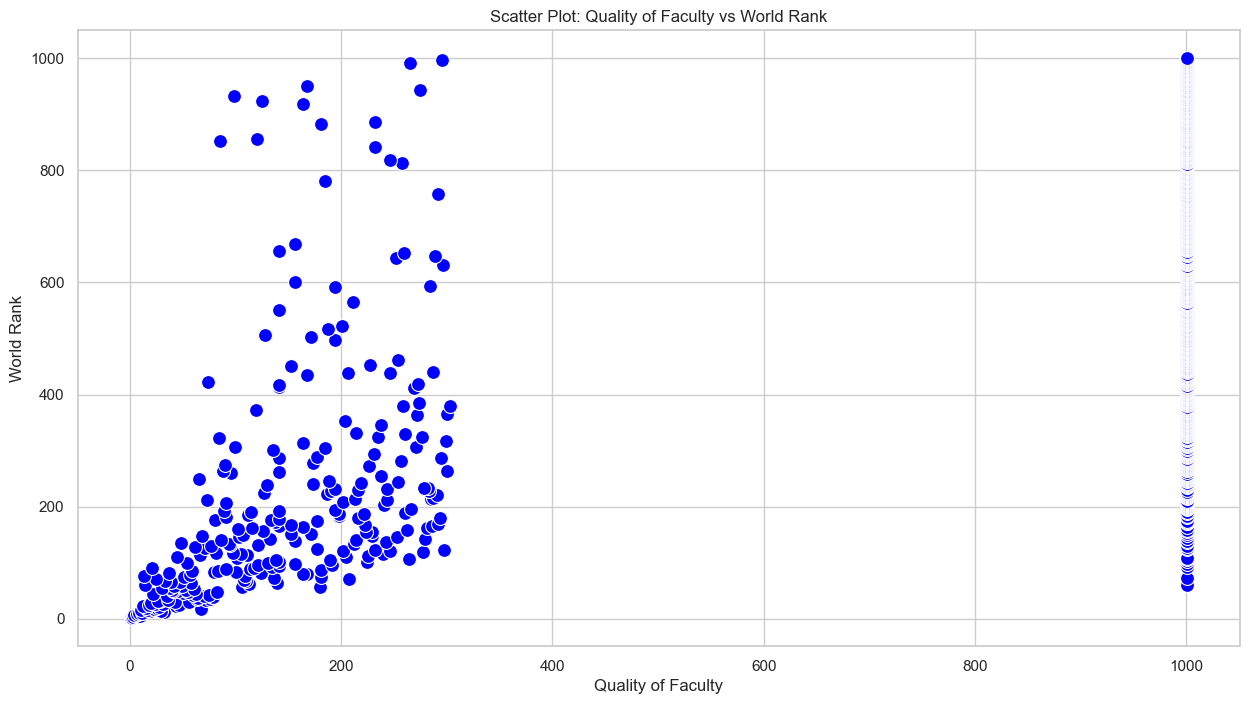

In [31]:
plt.figure(figsize=(15,8))
sns.set(style="whitegrid")

sns.scatterplot(
    x='Quality of Faculty',
    y='World Rank',  
    data=df,
    color='blue',
    s=100
)

plt.title('Scatter Plot: Quality of Faculty vs World Rank')
plt.xlabel('Quality of Faculty')
plt.ylabel('World Rank')

plt.savefig('plot_n4.png', dpi=300, bbox_inches='tight')
plt.show()

### Average Quality of Education by Country

C:\Users\moham\AppData\Local\Temp\ipykernel_9032\898632096.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=education_quality_by_country.values, y=education_quality_by_country.index, palette='viridis')


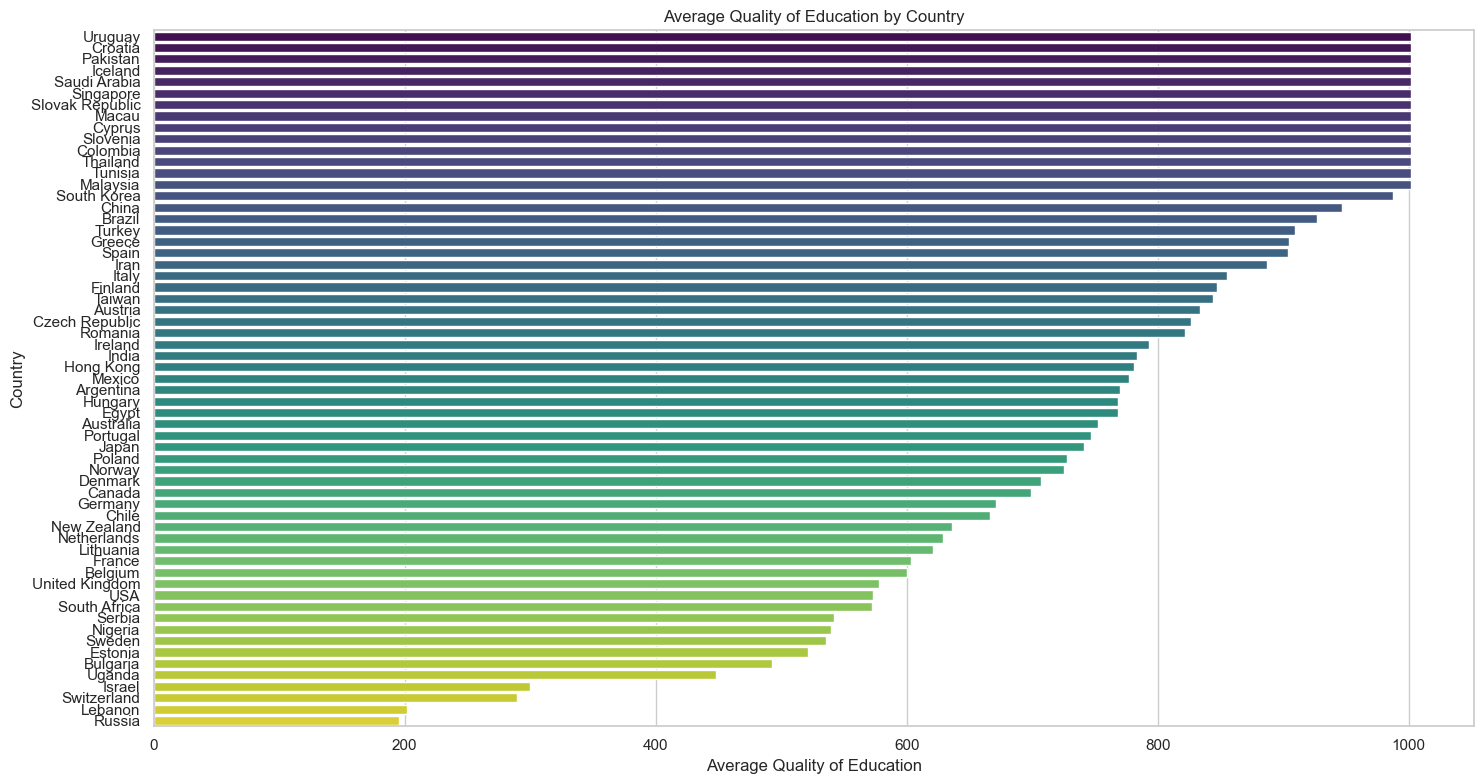

In [32]:

education_quality_by_country = df.groupby('Location')['Quality of Education'].mean().sort_values(ascending=False)
plt.figure(figsize=(15,8))
sns.barplot(x=education_quality_by_country.values, y=education_quality_by_country.index, palette='viridis')
plt.title('Average Quality of Education by Country')
plt.xlabel('Average Quality of Education')
plt.ylabel('Country')
plt.tight_layout()
plt.show()


### Average Quality of Education by Country whit number

C:\Users\moham\AppData\Local\Temp\ipykernel_9032\2763045376.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


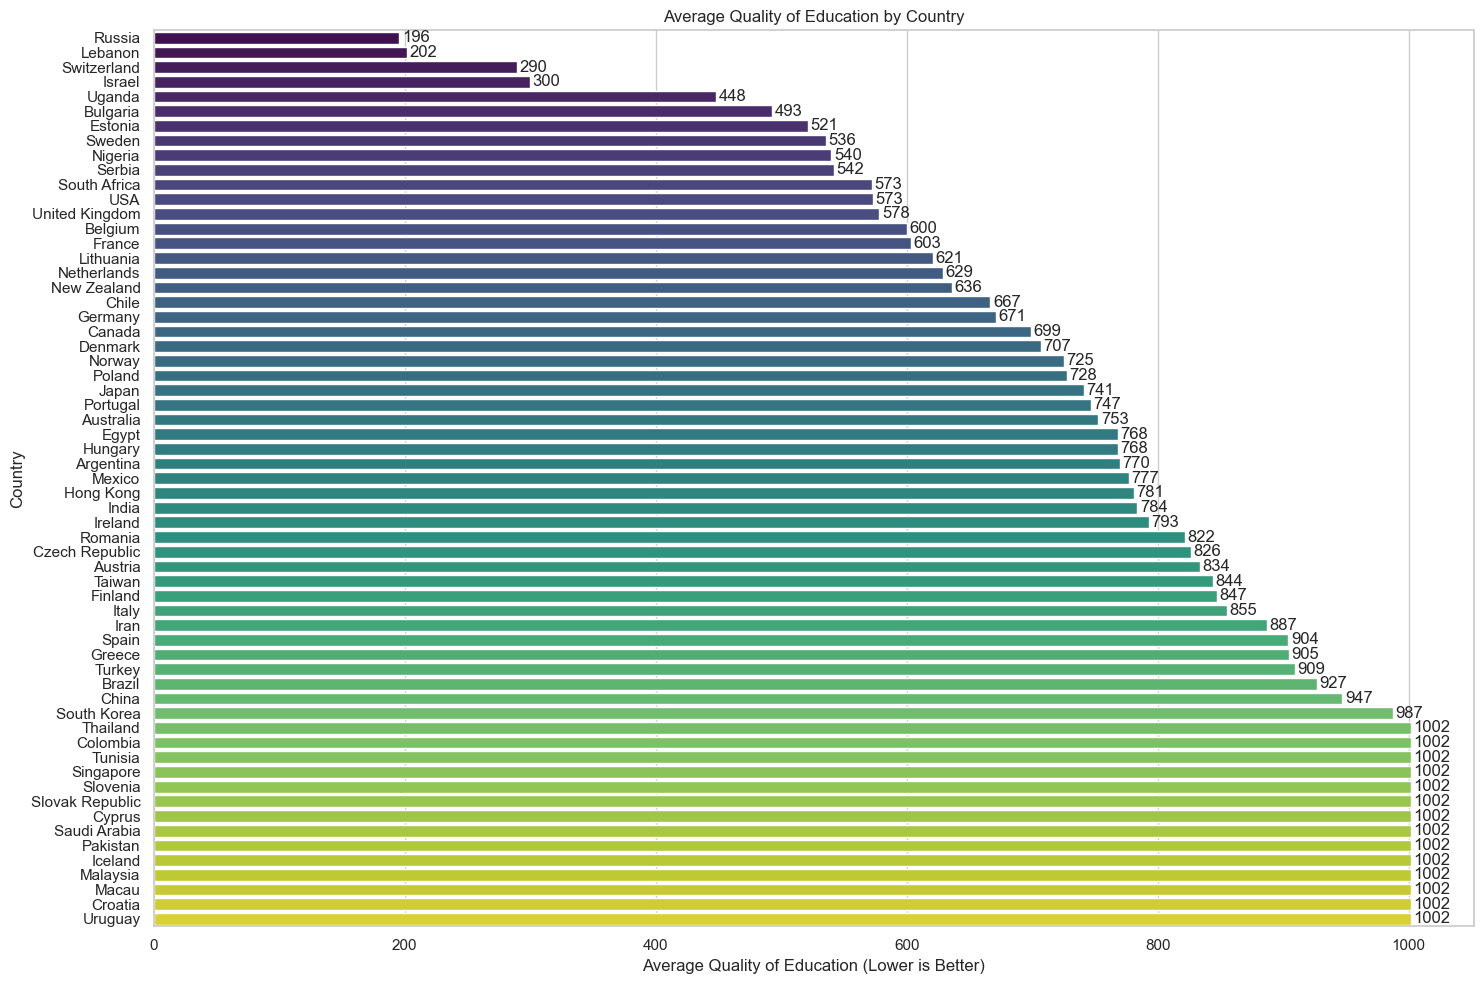

In [33]:

education_quality_by_country = df.groupby('Location')['Quality of Education'].mean()


education_quality_by_country = education_quality_by_country.sort_values()


education_quality_by_country = education_quality_by_country.dropna()


plt.figure(figsize=(15,10))
sns.set(style="whitegrid")

barplot = sns.barplot(
    x=education_quality_by_country.values,
    y=education_quality_by_country.index,
    palette='viridis'
)

plt.title('Average Quality of Education by Country')
plt.xlabel('Average Quality of Education (Lower is Better)')
plt.ylabel('Country')

for index, value in enumerate(education_quality_by_country.values):
    plt.text(
        value + 2,   
        index, 
        f'{value:.0f}', 
        va='center'
    )

plt.tight_layout()
plt.show()



### value count university in country

In [34]:
university_counts = df['Location'].value_counts()

print(university_counts)

Location
USA                213
China              108
United Kingdom      62
France              58
Japan               56
                  ... 
Uruguay              1
Slovak Republic      1
Estonia              1
Iceland              1
Macau                1
Name: count, Length: 61, dtype: int64


### value count university in country plot

C:\Users\moham\AppData\Local\Temp\ipykernel_9032\2040950215.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


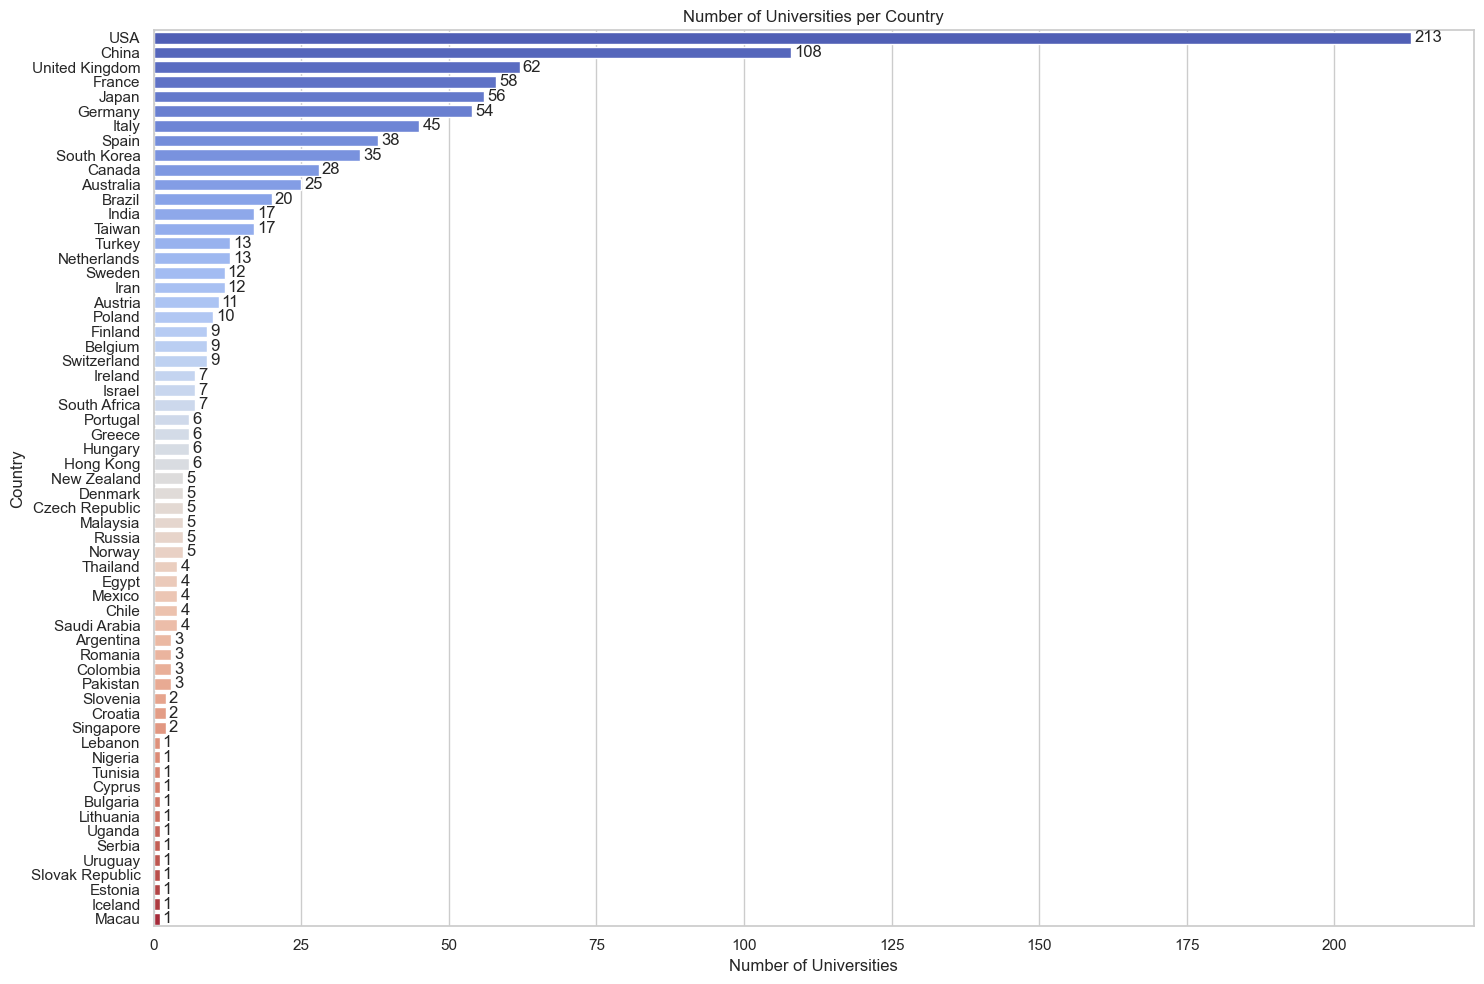

In [35]:
university_counts = df['Location'].value_counts()


plt.figure(figsize=(15,10))
sns.set(style="whitegrid")

sns.barplot(
    x=university_counts.values, 
    y=university_counts.index, 
    palette='coolwarm'
)

plt.title('Number of Universities per Country')
plt.xlabel('Number of Universities')
plt.ylabel('Country')
for index, value in enumerate(university_counts.values):
    plt.text(value + 0.5, index, str(value), va='center'

    )
plt.savefig('t1.jpg')
plt.tight_layout()
plt.show()

### Top 10 Countries by Quality of Education

C:\Users\moham\AppData\Local\Temp\ipykernel_9032\703921023.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(


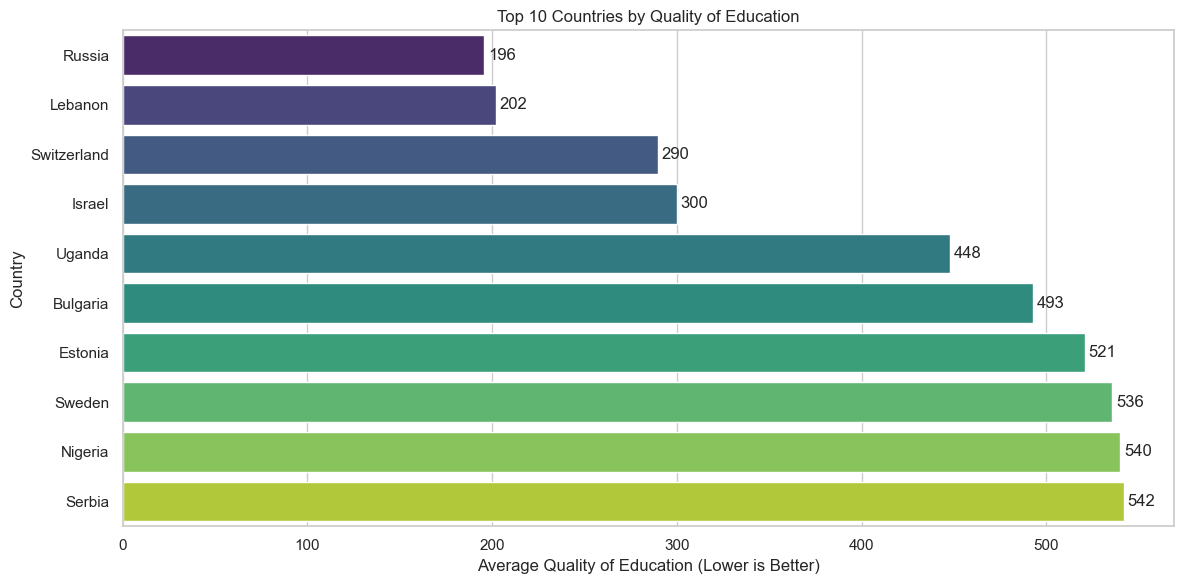

In [36]:
education_quality_by_country = df.groupby('Location')['Quality of Education'].mean()


education_quality_by_country = education_quality_by_country.sort_values()


top10_education_quality = education_quality_by_country.head(10)


plt.figure(figsize=(12,6))
sns.set(style="whitegrid")

barplot = sns.barplot(
    x=top10_education_quality.values,
    y=top10_education_quality.index,
    palette='viridis'
)

plt.title('Top 10 Countries by Quality of Education')
plt.xlabel('Average Quality of Education (Lower is Better)')
plt.ylabel('Country')


for index, value in enumerate(top10_education_quality.values):
    plt.text(
        value + 2, 
        index, 
        f'{value:.0f}', 
        va='center'
    )
plt.savefig('t2.jpg')
plt.tight_layout()
plt.show()

In [37]:
team = df.groupby(['Location','World Rank']).agg(
player_count=('Institution', 'count')
)
print(team)

                           player_count
Location       World Rank              
Argentina      293                    1
               545                    1
               762                    1
Australia      57                     1
               71                     1
...                                 ...
United Kingdom 920                    1
               983                    1
               984                    1
               988                    1
Uruguay        725                    1

[1000 rows x 1 columns]


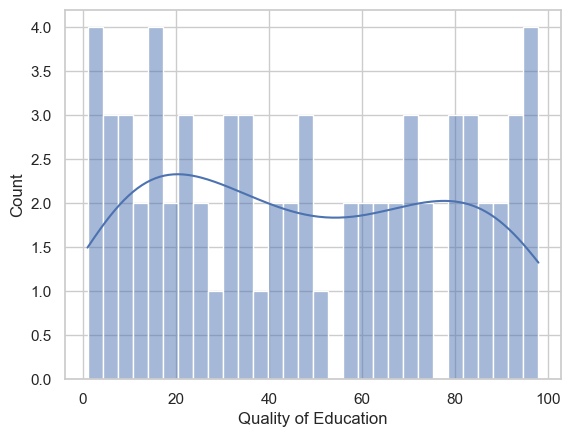

In [38]:
filtered_data = df[df['Quality of Education'] < 100]
plt.Figure(figsize=(18,5))
sns.histplot(filtered_data['Quality of Education'],bins=30,kde=True)
plt.show()

###  Countries by Institution

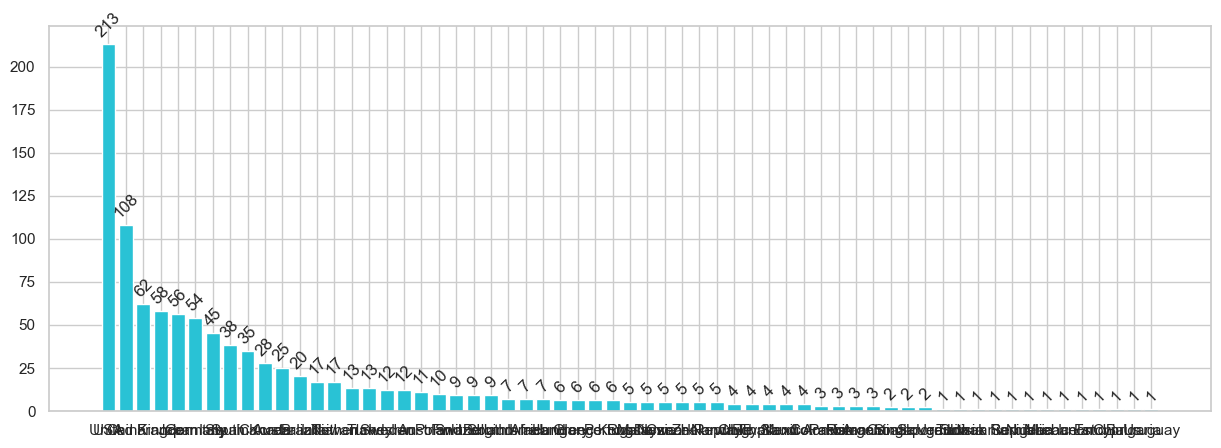

In [39]:
area_sum__location = df.groupby('Location')['Institution'].count().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(15, 5))
bars = ax.bar(area_sum__location.index, area_sum__location.values, color='#29c2d5')
ax.bar_label(bars, padding=3, fmt='%.0f',rotation=45)
plt.show()

In [40]:
df.columns

Index(['World Rank', 'Institution', 'Location', 'National Rank',
       'Quality of Education', 'Alumni Employment', 'Quality of Faculty',
       'Research Output', 'Quality Publications', 'Influence', 'Citations',
       'Score'],
      dtype='object')

### sum Score in country

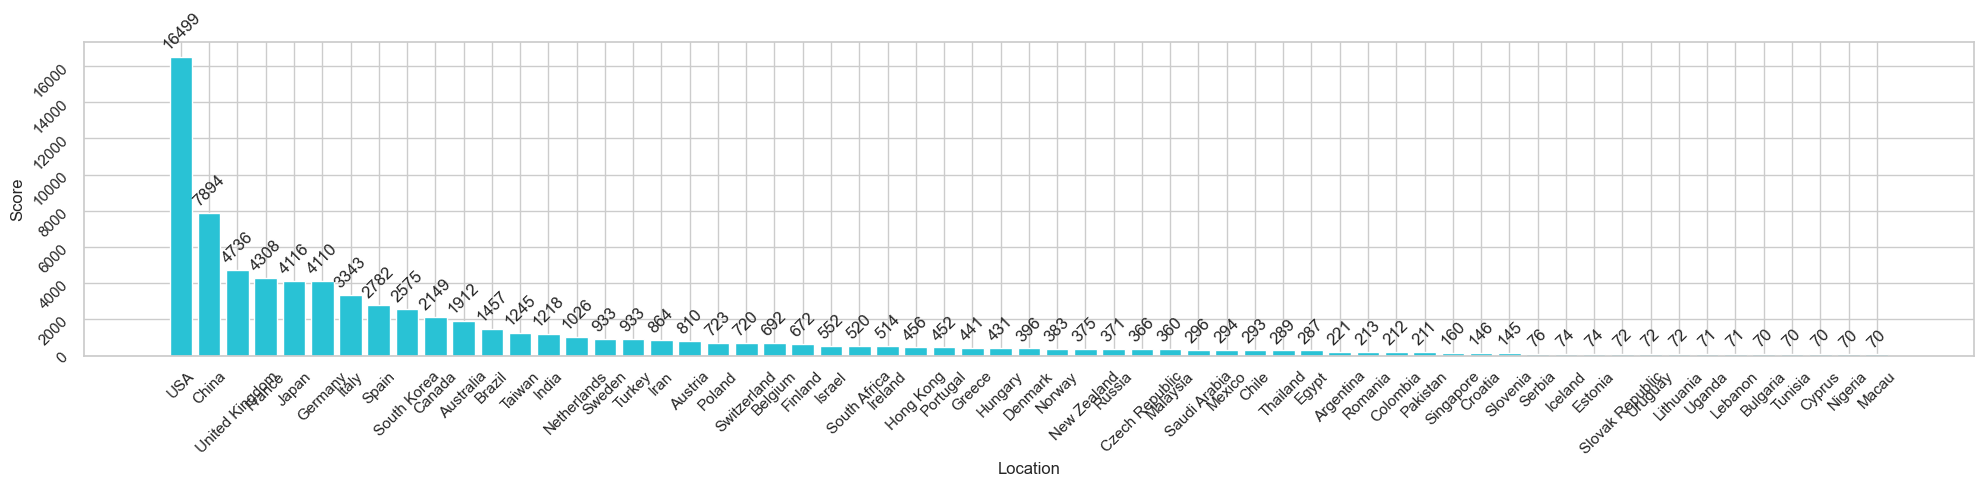

In [41]:
area_sum__location = df.groupby('Location')['Score'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(20, 5))
bars = ax.bar(area_sum__location.index, area_sum__location.values, color='#29c2d5')
ax.bar_label(bars, padding=3, fmt='%.0f',rotation=45)
ax.set_ylabel('Score')
ax.set_xlabel('Location')
plt.xticks(rotation=45)
plt.yticks(rotation =45)
plt.tight_layout()
plt.show()

### mean and sum Score in location

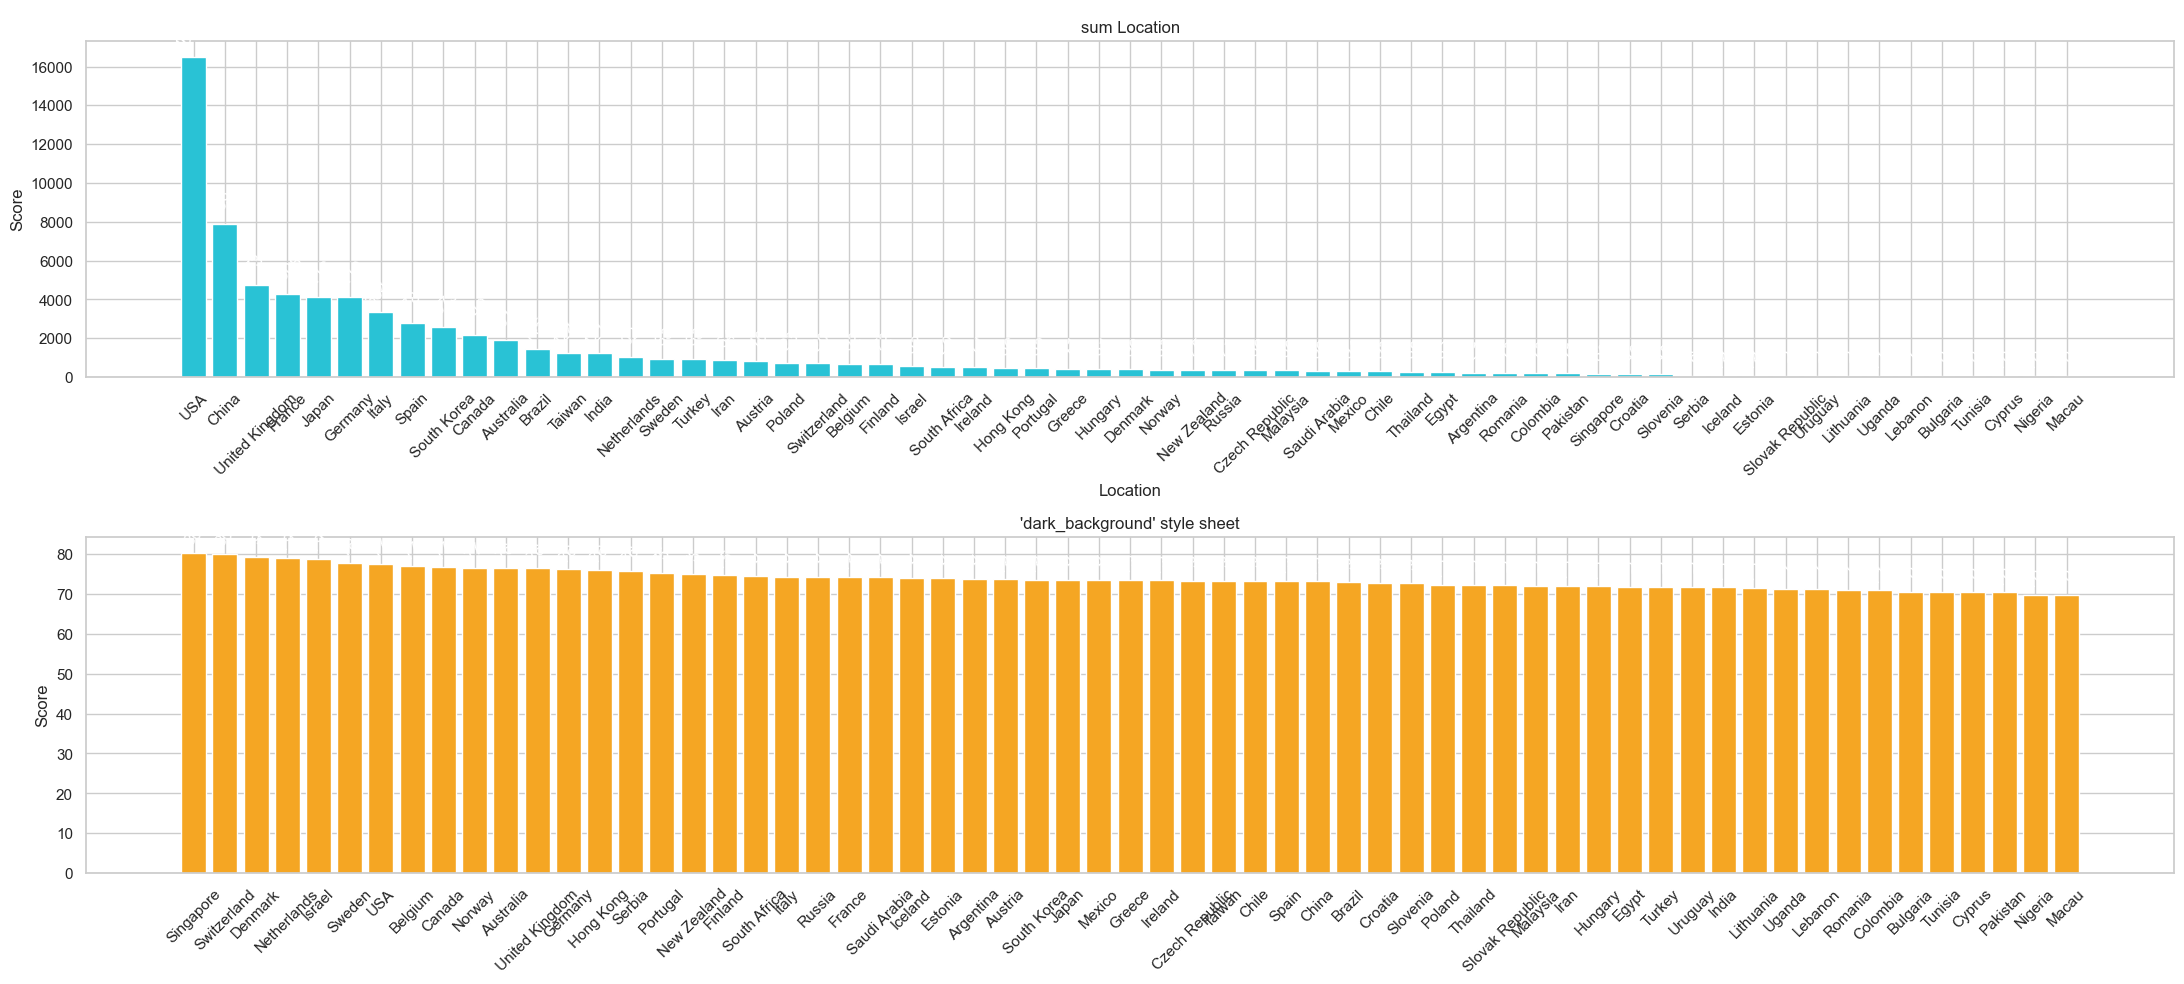

In [46]:

score_sum = df.groupby('Location')['Score'].sum().sort_values(ascending=False)
institution_count = df.groupby('Location')['Score'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(2, 1, figsize=(22, 10))
plt.style.use('dark_background')
bars1 = axes[0].bar(score_sum.index, score_sum.values, color='#29c2d5')
axes[0].bar_label(bars1, padding=3, fmt='%.0f',rotation=45)
axes[0].set_title('sum Location')
axes[0].set_xlabel('Location')
axes[0].set_ylabel('Score')
axes[0].tick_params(axis='x', rotation=45)

bars2 = axes[1].bar(institution_count.index, institution_count.values, color='#f5a623')
axes[1].bar_label(bars2, padding=3, fmt='%.0f',rotation=45)
axes[1].set_title('mean Location')
axes[1].set_ylabel('mean Score')
axes[1].set_ylabel('Score')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_title("'dark_background' style sheet")
plt.tight_layout()
plt.savefig('a.jpg')
plt.show()

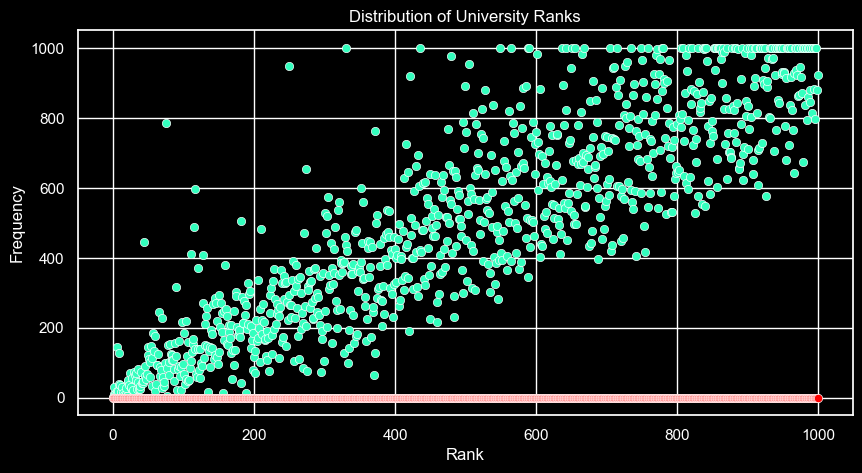

In [66]:
plt.style.use('dark_background')
f = df['Research Output']> df['Research Output'].max()
plt.figure(figsize=(10,5))
sns.scatterplot(df['Research Output'], color='#33ffbe')
sns.scatterplot(f,color='red')
plt.title("Distribution of University Ranks")
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.show()


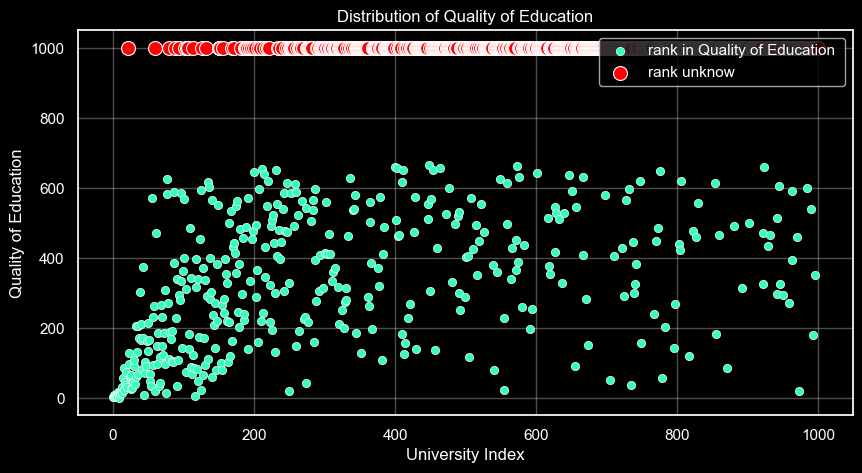

In [78]:
plt.style.use('dark_background')

plt.figure(figsize=(10,5))
normal = df[df['Quality of Education'] <= 1000]
highlight = df[df['Quality of Education'] > 1000]


sns.scatterplot(
    x=normal.index,
    y=normal['Quality of Education'],
    color='#33ffbe',
    label='rank in Quality of Education '
)


sns.scatterplot(
    x=highlight.index,
    y=highlight['Quality of Education'],
    color='red',
    s=100,
    label='rank unknow'
)

plt.title("Distribution of Quality of Education")
plt.xlabel("University Index")
plt.ylabel("Quality of Education")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.show()



In [43]:
df.columns

Index(['World Rank', 'Institution', 'Location', 'National Rank',
       'Quality of Education', 'Alumni Employment', 'Quality of Faculty',
       'Research Output', 'Quality Publications', 'Influence', 'Citations',
       'Score'],
      dtype='object')

KeyError: ''

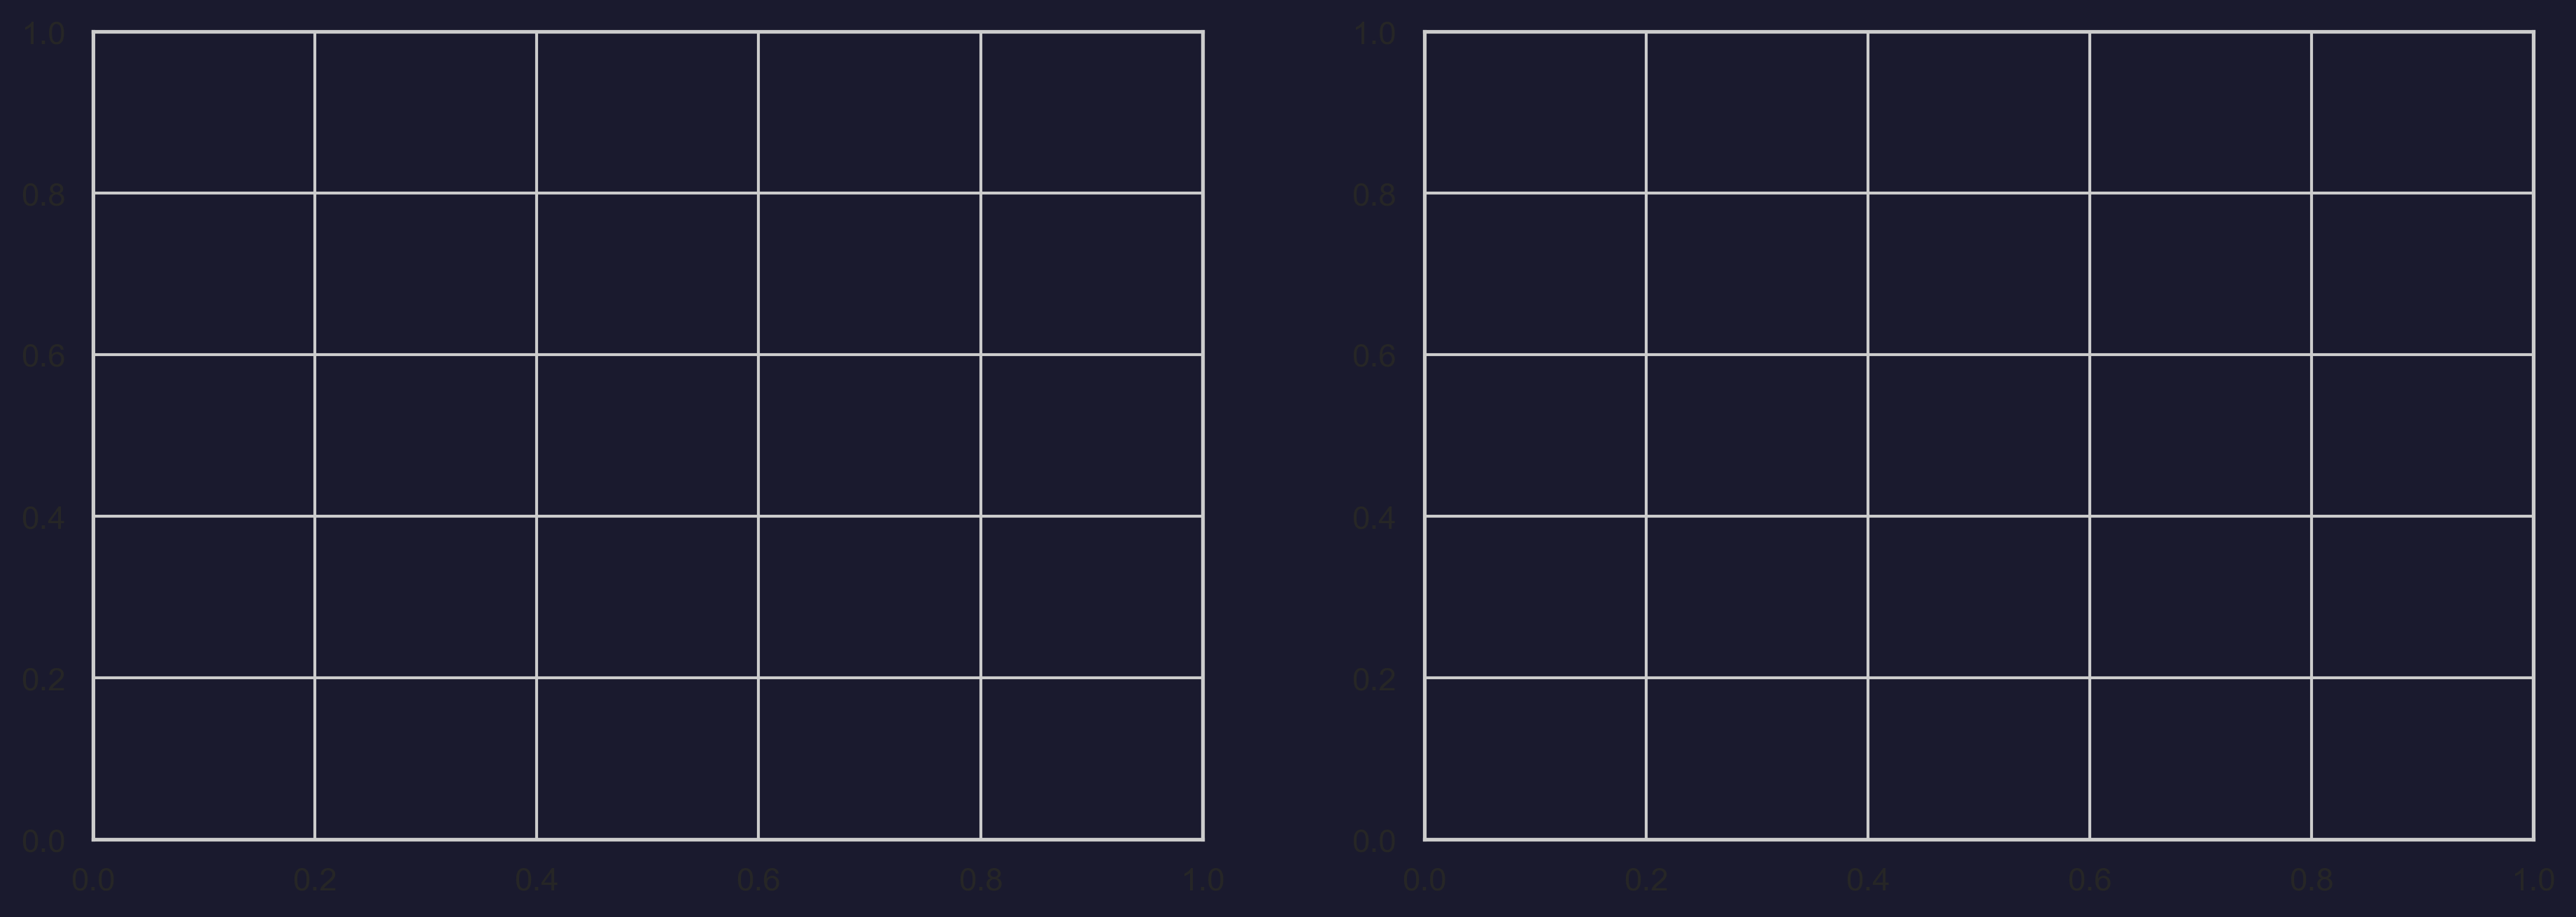

In [44]:
fig, ax = plt.subplots(1, 2, dpi=300, figsize=(15, 5))


fig.patch.set_facecolor("#1A1A2E")  
ax[0].set_facecolor("#1A1A2E")
ax[1].set_facecolor("#1A1A2E")


ax[0].scatter(df[''], df["yeild"], color="#0f5f2b", alpha=0.8, edgecolors="#aeff00",s=80)
ax[0].set_xlabel("Temperature")
ax[0].set_ylabel("yeild")

sns.histplot(df["Temperature"], bins=30, kde=True, ax=ax[1], color="#32e5d2")
ax[0].grid(True,alpha=0.99)
ax[1].grid(True,alpha=0.99)

for a in ax:
    a.spines['bottom'].set_color('white')
    a.spines['left'].set_color('white')
    a.xaxis.label.set_color('white')
    a.yaxis.label.set_color('white')
    a.title.set_color('white')
    a.tick_params(colors='white')


plt.show()